In [27]:
# import
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.stats import binom

from statsmodels.duration.hazard_regression import PHReg


# Histograms and the binomial distribution

Histograms provide a visual representation of the empirical distribution of a data set.

In this lab, we will simulate numerical experiments with random number generators to illustrate how histograms can be used to infer the true probability distribution of our random variables and the impact of finite data sets on our estimates.

For simplicity, we will start with an experiment with discrete random variables (the roll of a dice). In the second part of the lab, we will move on to continuous random variables.

## Part 1: Discrete Random Variables : The roll of a dice

Consider a discrete random variable \(Y\) that can take any of the possible values in $\{y_1,\ldots,y_n\}$. To estimate the probability of each value, $p_n$, we can count the frequency with which each $y_i$ occurs in our data set. This intuitive idea is justified by the law of large numbers, but we can easily illustrate it here by modeling the counting process with the binomial distribution.

For clarity, we assume that the true probability of observing $y_i$ is $p_i$.

The process of checking whether our random variable $y$ matches a given value $y_i$ (e.g., a particular digit in a die) can be treated as a Bernoulli trial assigned to the random variable $X_i$, where "success" ($x_i=0$) means that $Y=y_i$, and "failure" ($x_i=1$) means that $Y|\neq y_i$. Since we are describing histograms, we refer to the event $Y=y_i$, as $Y$ being in bin $i$.

In a set of $N$ trials (e.g., $N$ dice rolls), the number of times we observe $Y=y_i$ is also a random variable

$$K_i=\sum_{n=1}^N X_{i,n}.$$

As we discussed in class, $K_i$ follows a binomial distribution:
$$ P(K_i=k) =B(k,p,N)= \binom{N}{k} p_i^k (1-p_i)^{N-k} $$

**Exercises (analytical)**
1. Calculate the expected number of observations in bin \(x_i\) as a function of $p_i$ and $N$.
2. Determine the expected standard deviation (or error) from this theoretical mean for Bin $i$.

In [1]:
# obtain E[k] and Var[k] as a function of N and p
def compute_mu(N, p):
    return N * p


def compute_sigma2(N, p):
    return N * p * (1 - p)
    ... # expected standard deviation of k

### Counting repetitions

Our numerical experiment will mimic a dice rolling experiment. To do this, we will randomly generate dice numbers with a uniform distribution, count how many times we get each of the 6 digits, and try to estimate their respective probabilities from analysis of the data.

Now let's count how many times I observe a particular outcome in a series of $N$ trials.

**Exercise (numerical)**

3. We simulate rolling a die by uniformly generating a random number between 1 and 6, i.e., the probability of getting every possible digit is $p=1/6$. Prepare a function that returns the result of a set of $N$ trials

In [4]:
# We generate N random numbers, each corresponding to the number displayed after a die roll
# the function random.randint(A,B) generates a random number between A and B with uniform probability

def throw_dice(N):  # roll N dices
    values = []
    for i in range(N):
        value = random.randint(1, 6)  # roll a die
        values.append(value)
    return values

    ... # return the result of N dice rolls


# we show the series of numbers obtained with each throw of the dice
print(throw_dice(10))

[1, 4, 4, 3, 1, 2, 3, 6, 3, 1]


4. Now let's count how many times I observe a given outcome in a set of $N$ trials. To do this, follow the steps below:

    a. Define a function to count how many times each number occurs

In [ ]:
def count_elements(X, Nmax=6):
    count = np.zeros(Nmax, dtype=int)
    
    # Count occurrences of each value from 1 to Nmax
    for value in X:
        count[value - 1] += 1
    
    return count

N = 10

#Generate a sequences of numbers

X = throw_dice(N)
#we show the sequence
print(X)

# Print the number of times we get each number
print([str(i + 1) + ":" + str(c) for i, c in enumerate(count_elements(X))])

[3, 4, 1, 2, 2, 3, 2, 4, 3, 4]
[0 0 0 0 0 0]
['1:1', '2:3', '3:3', '4:3', '5:0', '6:0']


b. Plot the results on a bar graph and compare them to the theoretical mean and standard deviation.


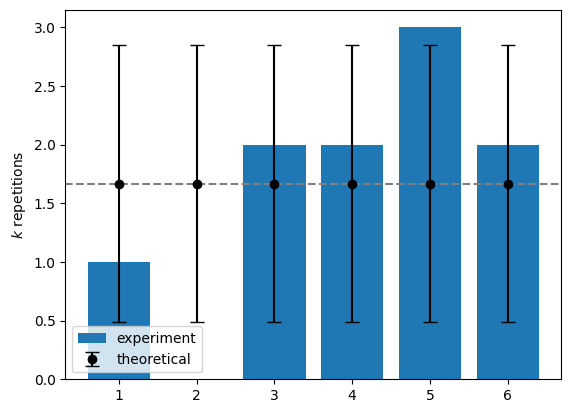

In [13]:
p = 1/6  # probability of getting any specific number on a fair dice
N = 10

mean = np.full(6, compute_mu(N, p))  # theoretical mean for each number
error = np.full(6, np.sqrt(compute_sigma2(N, p)))  # theoretical standard deviation for each number

# we plot the counts of each number
plt.bar(np.arange(1, 7), count_elements(throw_dice(N)), capsize=5, label='experiment')

#we compare with the theoretical expectation
plt.errorbar(np.arange(1, 7), mean, yerr=error, fmt='o', capsize=5, color='black', label='theoretical')
plt.axhline(y=mean[0], ls='--', color='gray')

plt.ylabel(r'$k$ repetitions')
plt.legend()
plt.show()

c. How does this change if you increase the number of die rolls per experiment?


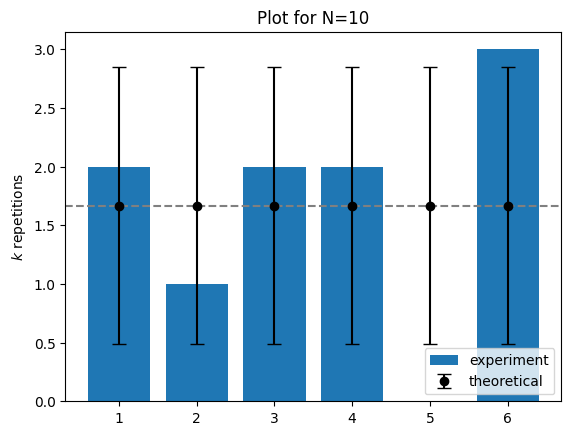

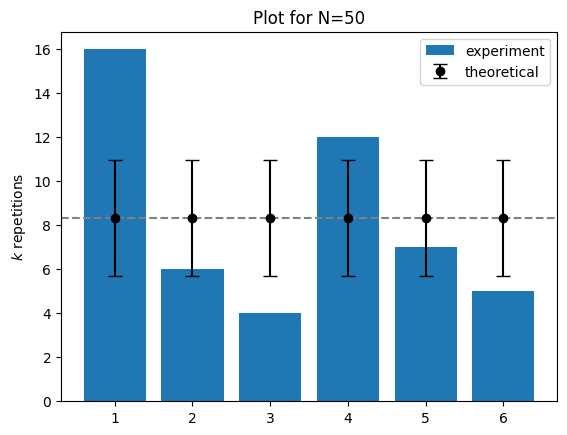

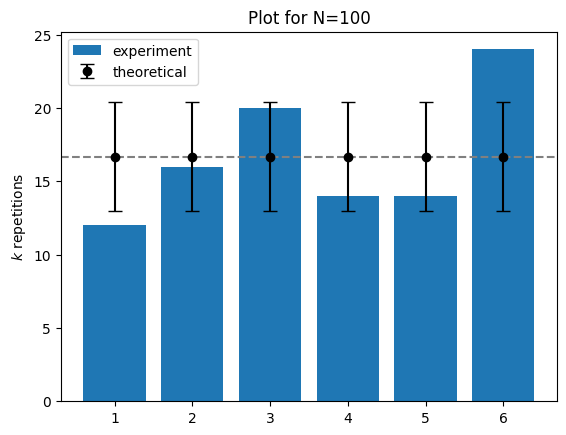

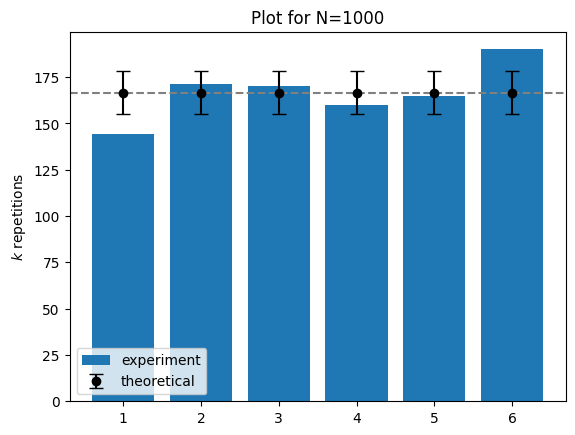

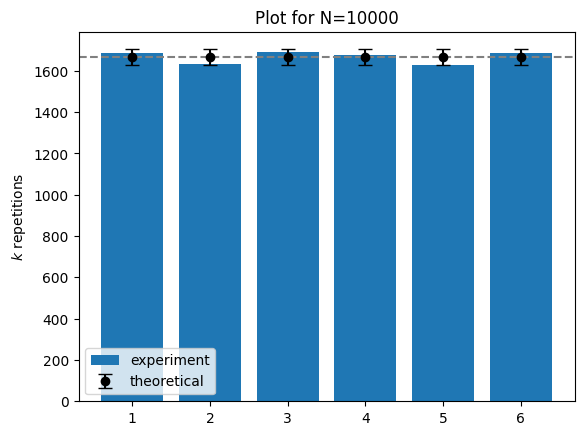

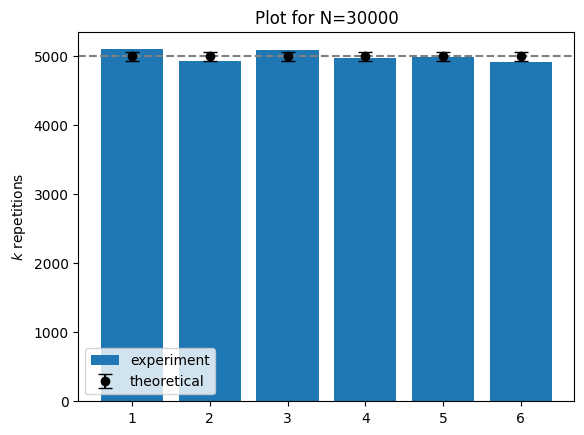

In [16]:
p = 1 / 6.

for N in [10, 50, 100, 1000, 10000, 30000]:
    mean = np.full(6, compute_mu(N, p))  # theoretical mean for each number
    error = np.full(6, np.sqrt(compute_sigma2(N, p)))# theoretical standard deviation

    # we plot the counts of each number
    plt.bar(np.arange(1, 7), count_elements(throw_dice(N)), capsize=5, label='experiment')

    #we compare with the theoretical expectation
    plt.errorbar(np.arange(1, 7), mean, yerr=error, fmt='o', capsize=5, color='black', label='theoretical')
    plt.axhline(y=mean[0], ls='--', color='gray')

    plt.ylabel(r'$k$ repetitions')
    plt.title(f'Plot for N={N}')
    plt.legend()
    plt.show()


You can repeat the experiment several times and you will get different results. Most likely, you will get several counts that do not agree the expected value and the expected variation. Does this mean that there is a problem with the random number generator? The general answer is: it depends.

If we know the theoretical distribution, the binomial distribution, we can calculate the probability that it will not match the error

$$(\mu-\sigma > k > \mu+\sigma)=1-P(\mu-\sigma < k < \mu+\sigma)=1-\sum_{k=[\mu-\sigma]}^{[\mu+\sigma]} B(k,N,p)$$

d. For the above values of $N$, estimate the probability that the number of hits within the error is inconsistent with the theoretical values. How many of our counts do we expect to be inconsistent with the expected values?

In [ ]:
from scipy.stats import binom  # we can compute the Binomial distribution

# using the code binom.pmf(k, N, p)


for N in [10, 100, 1000, 10000]:
    sum_prob = 0

    p = ...
    mean = ...
    error = ...

    min_k = ...
    max_k = ...
    print(f'min_k={min_k}, max_k={max_k}')

    for k in range(min_k, max_k + 1):
        sum_prob += ...

    prob_out = 1 - sum_prob
    print(f'N={N}: prob = {prob_out} out of six: {prob_out * 6}')

### Normalized histogram

Instead of wondering about how often the die gives a certain number as a result, let us use it to estimate the frequency with which we get each of the numbers, which can be used as an approximation for the real probability $p_n$. The frequency is nothing more than the number of success numbers in my bin divided by the total number of trials. In other words, we now want to describe the statistics of normalized random variable:

$Z_i=\frac{1}{N}\sum_{n=0}^N X_{i,n}=\frac{K_i}{N}$

where $X_i$ is the random variable corresponding to the Bernoilli trial of being in bin $i$.

5. Which is the theoretical mean and the expected standard deviaton of this new normalized variable?



In [21]:
def compute_normalized_mu(N, p):
    return p
    ...  # mean of Z


def compute_normalized_sigma2(N, p):
    return p * (1 - p) / N
    ...  # stardard deviation of Z

6. Compute the the empirical frequency of appearance of each of the 6 numbers and compare them with the expected value and expected standard deviation. How accurate is this estimation as $N$ grows?

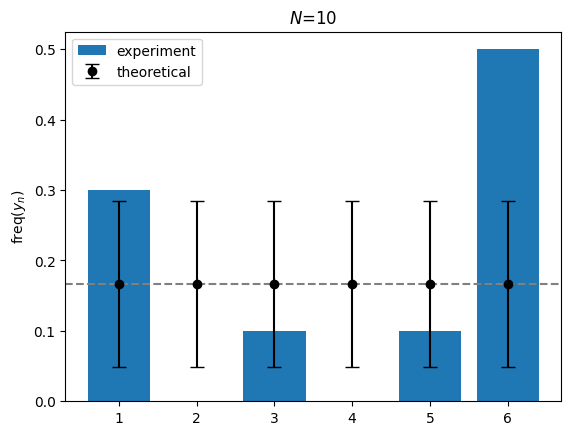

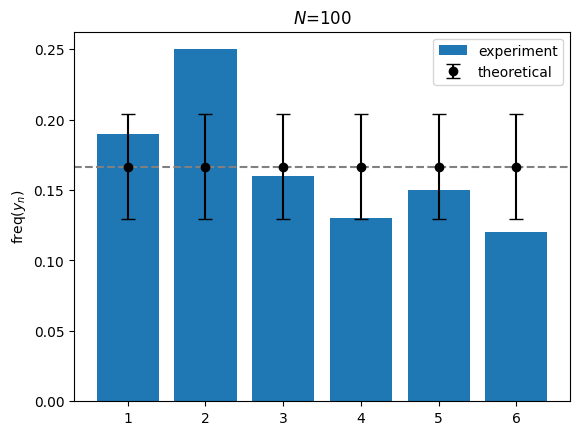

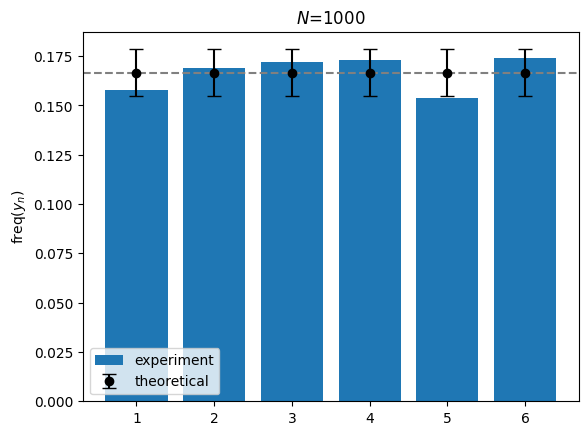

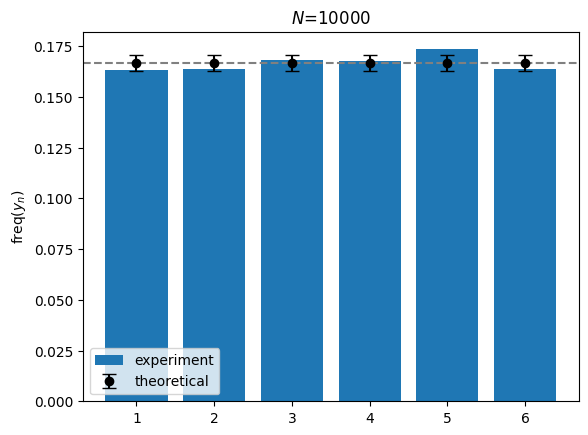

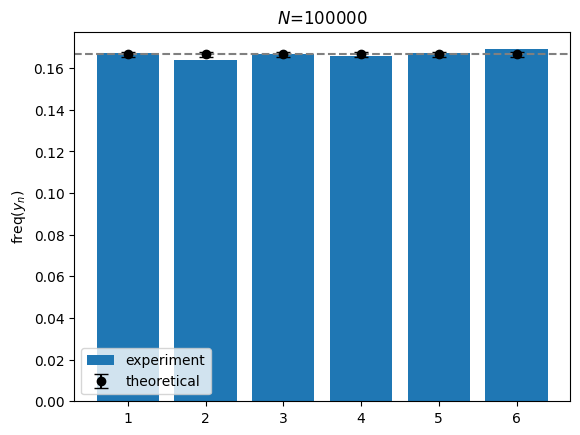

In [23]:
p = 1 / 6

for N in [10, 100, 1000, 10000, 100000]:
    mean = np.array([p] * 6)  # mean of Z for all 6 outcomes
    error = np.array([np.sqrt(p * (1 - p) / N)] * 6)  # standard deviation of Z for all 6 outcomes
    
    # Simulate rolling a die N times
    rolls = np.random.randint(1, 7, size=N)  # Random integers from 1 to 6
    
    # Count frequency of each outcome and normalize
    frequency = np.array([np.sum(rolls == i) / N for i in range(1, 7)])


    plt.bar(np.arange(1, 7), frequency, capsize=5, label='experiment')
    plt.errorbar(np.arange(1, 7), mean, yerr=error, fmt='o', capsize=5, color='black', label='theoretical')

    plt.title(r'$N$=' + str(N))
    plt.axhline(y=1. / 6., ls='--', color='gray')
    plt.ylabel(r'freq$(y_n)$')
    plt.legend()

    plt.show()

### Central limit theorem

The law of large numbers states that $\mu_Z \to p$ as $N\to\infty$, and that $\sigma^2_Z=\frac{\sigma_K^2}{N}$. This ensures that as the number of repetitions $N$ increases, our estimate of the probability of each event becomes finer and finer, but also that the expected fluctuations become smaller and smaller!

The central limit theorem goes even further: it states that $Z$ becomes Gaussian distributed $\mathcal{N}(\mu,\sigma^2)$ as the number of repetitions $N$ increases.

7. We have argued that $K_i=N Z_i$ (and hence $Z$) is distributed as a binomial distribution. We can verify that this is indeed the case by repeating our experiment (rolling $N$ dices) $T=1000$ times. And examine the histogram of the results with the binomial and normal distributions. Follow the steps below to do this:

 a. Now consider repeating the same experiment T times and record the number of repetitions you get for each of the numbers. Since all the numbers have the same probability, we can add up all the results in the same vector of values of k_i.

 b. Calculate a histogram of the ks obtained to estimate the frequency with which we obtain each value.
 Plot k/N against this frequency.

 c. Compare the shape of the histograms as you change $N$

 d. For each value of $N$ compare the empirical frequency with the binomial and the normal distribution


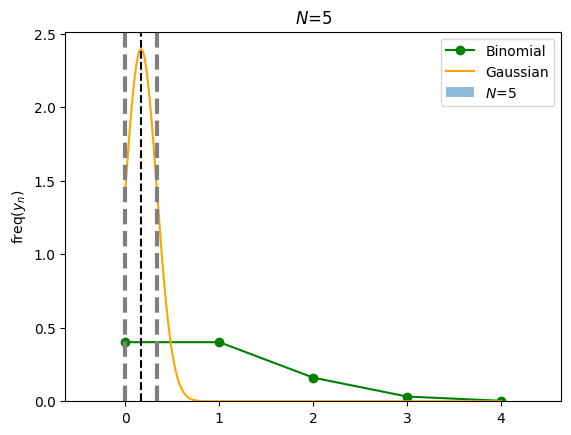

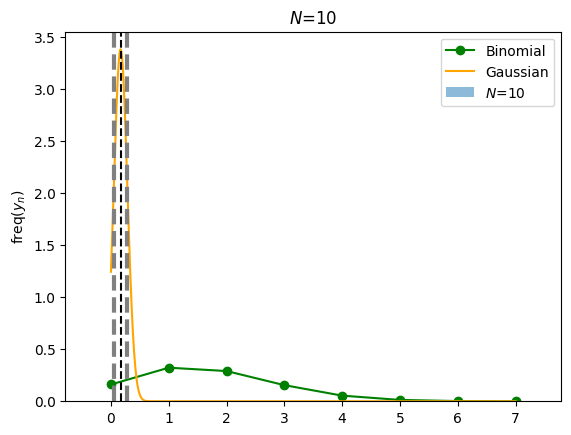

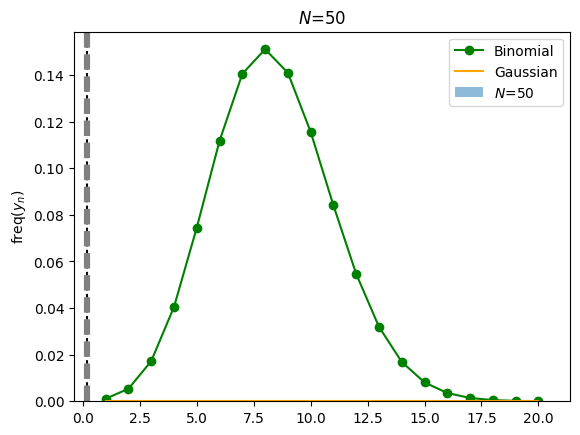

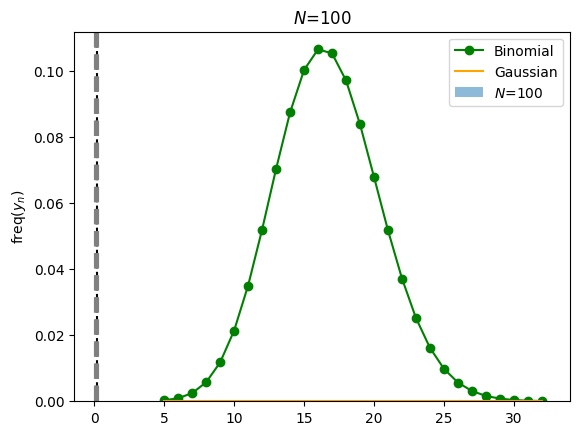

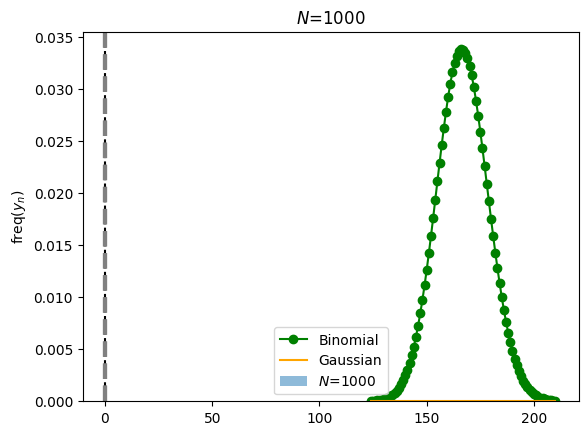

In [29]:
def gauss(x, mu, sigma2):
    return (1 / np.sqrt(2 * np.pi * sigma2)) * np.exp(-0.5 * (x - mu)**2 / sigma2)
    ...  # Gaussian density function


def count_elements_integer(X):
    Nmin = np.min(X)
    Nmax = np.max(X)

    count = np.zeros(Nmax - Nmin + 1)
    # fill the count array with the number of times we find a Nmin, Nmin+1, ...
    return np.arange(Nmin, Nmax + 1), count.astype(int)


T = 1000
p = 1 / 6

for N in [5, 10, 50, 100, 1000]:

    Results = np.zeros((T, 6))
    for t in range(T):
        rolls = np.random.randint(1, 7, size=N)
        Results[t] = np.array([np.sum(rolls == i) for i in range(1, 7)]) # roll N dices and count the number of occurences of each number

    pk = Results.reshape(6 * T).astype(
        int)  # Since all numbers have the same probability, we can add up all the statistics of all them for the analysis

    myrange, myhist = count_elements_integer(pk)

    plt.bar(myrange, myhist / (6 * T), label=r'$N$=' + str(N), alpha=0.5)

    # binomial probability
    bi_prob = binom.pmf(myrange, N, p) # probability mass for each value in myrange
    plt.plot(myrange, bi_prob, 'o-', color='green', label='Binomial')

    x = np.linspace(myrange[0], myrange[-1], 1000)
    mu = compute_normalized_mu(N, p)
     # mean of Z --- IGNORE ---
    sigma2 = compute_normalized_sigma2(N, p)
     # variance of Z --- IGNORE ---
    plt.plot(x, gauss(x, mu, sigma2), color='orange', label='Gaussian')

    plt.axvline(x=mu, ls='--', color='black')
    plt.axvline(x=mu - np.sqrt(sigma2), ls='--', lw=3, color='gray')
    plt.axvline(x=mu + np.sqrt(sigma2), ls='--', lw=3, color='gray')
    plt.ylabel(r'freq$(y_n)$')
    plt.title(r'$N$=' + str(N))
    plt.legend()

    plt.show()


### Area under the Gaussian

We want to estimate the probability of getting values at certain distance of the expected value.
For this it is convenient to use the **error function**:

$$erf(z)=\frac{2}{\sqrt{\pi}}\int_0^z e^{-x^2}$$

Using this function, the cumulative distribution function of the $\mathcal{N}(\mu,\sigma)(x)$ is
$$F(x | \mu, \sigma^2) = \frac{1}{2} \left[ 1 + \text{erf}\left(\frac{x - \mu}{\sigma\sqrt{2}}\right) \right]$$

And the area between two values $a$ and $b$
$$\text{Area between } a \text{ and } b = F(b | \mu, \sigma^2) - F(a | \mu, \sigma^2)$$


(i) Proof these two expressions

(ii) Estimate the probability of  $|k-\mu|>\sigma$, $|k-\mu|>2\sigma$, $|k-\mu|>3\sigma$

In [38]:
from scipy.special import erf


def gaussian_area(a, b):
    F_b = 0.5 * (1 + erf(b / np.sqrt(2)))
    F_a = 0.5 * (1 + erf(a / np.sqrt(2)))
    return F_b - F_a
    ... # area between a and b for a Gaussian distribution (use the error function)

p = 1/6
N = 10
mu = compute_mu(N, p)
sigma = np.sqrt(compute_sigma2(N, p))

area_under_curve_1sigma = gaussian_area(-1, 1)
probability_out_1sigma = 1 - area_under_curve_1sigma
print(f'Area under the curve for |k-μ| ≤ 1σ: {area_under_curve_1sigma:.4f}')

# For |k - mu| > 2*sigma
area_under_curve_2sigma = gaussian_area(-2, 2)
probability_out_2sigma = 1 - area_under_curve_2sigma

# For |k - mu| > 3*sigma
area_under_curve_3sigma = gaussian_area(-3, 3)
probability_out_3sigma = 1 - area_under_curve_3sigma

print(f'\nProbability of being outside 1 sigma: {probability_out_1sigma:.4f}')
print(f'Probability of being outside 2 sigma: {probability_out_2sigma:.4f}')
print(f'Probability of being outside 3 sigma: {probability_out_3sigma:.4f}')

Area under the curve for |k-μ| ≤ 1σ: 0.6827

Probability of being outside 1 sigma: 0.3173
Probability of being outside 2 sigma: 0.0455
Probability of being outside 3 sigma: 0.0027


## Part 2: Continous random variables

Normally, our random variables have continuous support. In such cases, the situation is very similar to the previous one, but now we discretize the support to form bins. Once the bins are defined, everything said before about the binomial distribution applies. As before, we can consider the non-normalized version, where we only count the number of hits in that bin, or the normalized case, where we need to normalize not only by the number of entries, but also by the size of the bin, if we want to obtain a function whose integral is 1.

Now we generate numbers following an exponential distribution

$$
f(x,\lambda) =
\begin{cases}
\lambda e^{-\lambda x} & \text{for } x \geq 0 \\
0 & \text{for } x < 0
\end{cases}
$$

1. Obtain the expected value of $X$ and the Variance.


In [ ]:
# Parameters
lamb = 1.0
N = 1000  # Number of random numbers to generate

va = np.random.exponential(scale=1/lamb, size=N) # generate N random numbers following an exponential distribution


def f(x, lamb):
    """Exponential density function"""
    return lamb * np.exp(-lamb * x) * (x >= 0)


def compute_mu(lamb):
    """Expected value of X for exponential distribution"""
    return 1 / lamb


def compute_sigma2(lamb):
    """Variance of X for exponential distribution"""
    return 1 / (lamb**2)


# Verify the results
print(f"Theoretical mean: {compute_mu(lamb):.4f}")
print(f"Sample mean: {np.mean(va):.4f}")
print(f"\nTheoretical variance: {compute_sigma2(lamb):.4f}")
print(f"Sample variance: {np.var(va):.4f}")
print(f"\nTheoretical std dev: {np.sqrt(compute_sigma2(lamb)):.4f}")
print(f"Sample std dev: {np.std(va):.4f}")

Theoretical mean: 1.0000
Sample mean: 0.9685

Theoretical variance: 1.0000
Sample variance: 0.9182

Theoretical std dev: 1.0000
Sample std dev: 0.9582


2. Create a function to obtain a normalized histogram of an array of numbers

3. Which are the expected values for each interval?

[330. 226. 144. 105.  64.  49.  23.  15.  17.   9.   4.   6.   1.   2.
   1.   1.   1.   1.   0.   1.]
[0.85426502 0.58504211 0.37277019 0.2718116  0.16567564 0.12684541
 0.05953968 0.03883023 0.04400759 0.02329814 0.01035473 0.01553209
 0.00258868 0.00517736 0.00258868 0.00258868 0.00258868 0.00258868
 0.         0.00258868]


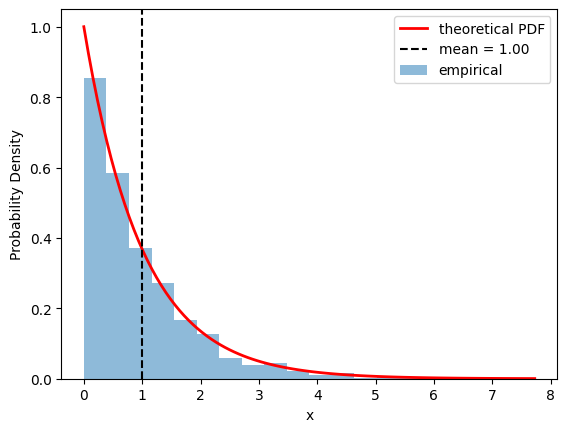

In [51]:
# do an histogram
def count_elements(seq, NBins):
    BInf = np.min(seq)  # minimum value of seq
    BSup = np.max(seq)  # maximum value of seq
    δ = (BSup - BInf) / NBins

    bins = np.linspace(BInf + δ / 2, BSup - δ / 2, NBins)
    norm = len(seq) * δ
    hist = np.zeros(NBins)
    
    # fill the hist array with the number of times we find a number in each bin
    for value in seq:
        # Find which bin this value belongs to
        bin_index = int((value - BInf) / δ)
        # Make sure we don't go out of bounds (for values exactly at BSup)
        if bin_index >= NBins:
            bin_index = NBins - 1
        hist[bin_index] += 1

    return hist, norm, bins, δ  # bins gives an array with the mid point in the interval


Nb = 20

h1, norm, bins, δ = count_elements(va, Nb)
print(h1)  # unnormalized
print(h1 / norm)  # normalized

x = bins
# plot the normalized histogram
plt.bar(bins, h1 / norm, width=δ, alpha=0.5, label='empirical')

# theoretical distribution - plot the exponential PDF
x_theory = np.linspace(0, np.max(va), 100)
plt.plot(x_theory, f(x_theory, lamb), 'r-', linewidth=2, label='theoretical PDF')

# Mark the mean
plt.axvline(compute_mu(lamb), color='black', linestyle='--', label=f'mean = {compute_mu(lamb):.2f}')

plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

4. Repeat the experiment $T=1000$ times and plot the distribution of the average of $X$, and compare with the Gaussian distribution expected.

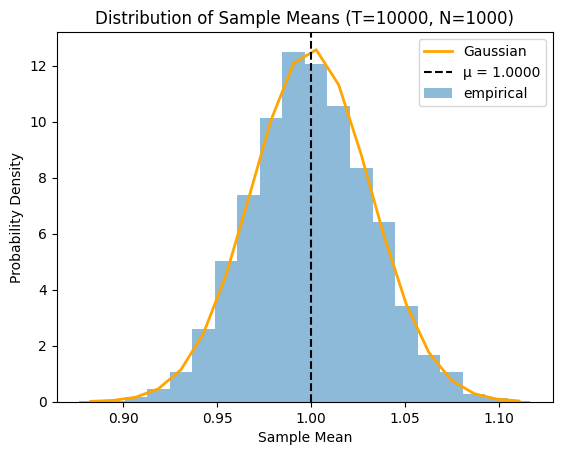

Theoretical mean: 1.0000
Empirical mean: 0.9998
Theoretical std dev: 0.0316
Empirical std dev: 0.0319


In [52]:
T = 10000
N = 1000
Results = np.zeros(T)
for t in range(T):
    # Generate N random numbers and compute their average
    Results[t] = np.mean(np.random.exponential(scale=1/lamb, size=N))

Nb = 20
h1, norm, bins, δ = count_elements(Results, Nb)
x = bins

# Gaussian distribution parameters
# Mean of the sample mean = mean of original distribution
mu = compute_mu(lamb)
# Variance of the sample mean = variance of original distribution / N
sigma2 = compute_sigma2(lamb) / N

plt.plot(x, gauss(x, mu, sigma2), color='orange', linewidth=2, label='Gaussian')

plt.axvline(x=mu, ls='--', color='black', label=f'μ = {mu:.4f}')
plt.bar(bins, h1 / norm, width=δ, alpha=0.5, label='empirical')
plt.xlabel('Sample Mean')
plt.ylabel('Probability Density')
plt.title(f'Distribution of Sample Means (T={T}, N={N})')
plt.legend()
plt.show()

print(f"Theoretical mean: {mu:.4f}")
print(f"Empirical mean: {np.mean(Results):.4f}")
print(f"Theoretical std dev: {np.sqrt(sigma2):.4f}")
print(f"Empirical std dev: {np.std(Results):.4f}")